In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

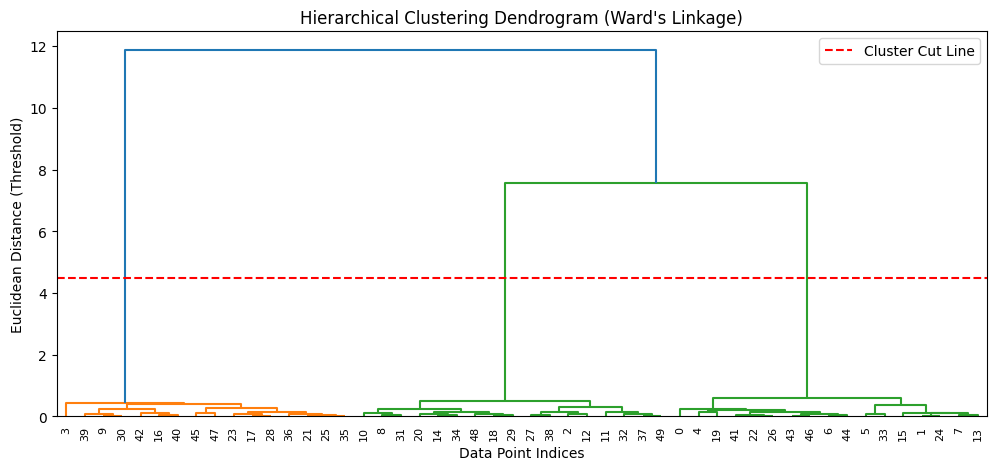

=== Hierarchical Clustering Output ===
First 10 Assigned Cluster Labels: [0 0 2 1 0 0 0 0 2 1]


In [1]:
#Topic 133 | Introduction to Hierarchical Clustering
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1. Dataset generate karein (Naturally 3 groups)
X, _ = make_blobs(n_samples=50, centers=3, cluster_std=0.60, random_state=42)

# Distance-based algorithm hai, isliye scaling zaroori hai
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------------
# STEP 2: SciPy ka use karte hue Dendrogram Plot Karein
# ------------------------------------------------------------------
# Hum Ward's linkage method use kar rahe hain matrix generate karne ke liye
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward's Linkage)")
plt.xlabel("Data Point Indices")
plt.ylabel("Euclidean Distance (Threshold)")
plt.axhline(y=4.5, color="r", linestyle="--", label="Cluster Cut Line")
plt.legend()
plt.show()

# ------------------------------------------------------------------
# STEP 3: Scikit-Learn ke sath Final Cluster Labels Assign Karein
# ------------------------------------------------------------------
# Dendrogram dekh kar agar hum threshold set karein, toh humein 3 clusters milte hain
agg_cluster = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
labels = agg_cluster.fit_predict(X_scaled)

print("=== Hierarchical Clustering Output ===")
print(f"First 10 Assigned Cluster Labels: {labels[:10]}")

In [3]:
# Topic 134 | Hierarchical Clustering - Agglomerative vs Divisive Methods
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage  # Fixed: removed tree_to_labels
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

# 1. Chota synthetic dataset generate karein (Sirf 6 points taake trace karna aasan ho)
X, _ = make_blobs(n_samples=6, centers=2, n_features=2, random_state=42)

print("=== DATA POINTS COORDINATES ===")
for idx, point in enumerate(X):
    print(f"Point {idx}: [{point[0]:.2f}, {point[1]:.2f}]")
print("-" * 50)

# ------------------------------------------------------------------
# APPROACH: Agglomerative Bottom-Up Linkage Tracking
# ------------------------------------------------------------------
# SciPy ka linkage function humein batata hai kaunse points kis step par merge huay
Z = linkage(X, method="ward")

print("\n=== AGGLOMERATIVE MERGE HISTORY (Bottom-Up) ===")
# Linkage matrix format: [Cluster A, Cluster B, Distance, New Cluster Size]
for i, step in enumerate(Z):
    print(
        f"Step {i+1}: Cluster {int(step[0])} aur Cluster {int(step[1])} aapas mein merge huay. "
        f"Distance: {step[2]:.4f} | Total points in new cluster: {int(step[3])}"
    )

# ------------------------------------------------------------------
# Scikit-Learn Model Configuration
# ------------------------------------------------------------------
# Hum model ko force kar sakte hain ke humein aakhri step par 2 clusters chahiye
agg_model = AgglomerativeClustering(n_clusters=2, metric="euclidean", linkage="ward")
labels = agg_model.fit_predict(X)

print("\n=== FINAL CLUSTER LABELS (For 2 Target Clusters) ===")
print(f"Data Points Assigned Labels: {labels}")

=== DATA POINTS COORDINATES ===
Point 0: [-2.74, 8.78]
Point 1: [4.88, 0.06]
Point 2: [2.91, 1.41]
Point 3: [4.18, 1.51]
Point 4: [-0.93, 9.78]
Point 5: [-2.98, 9.56]
--------------------------------------------------

=== AGGLOMERATIVE MERGE HISTORY (Bottom-Up) ===
Step 1: Cluster 0 aur Cluster 5 aapas mein merge huay. Distance: 0.8116 | Total points in new cluster: 2
Step 2: Cluster 2 aur Cluster 3 aapas mein merge huay. Distance: 1.2652 | Total points in new cluster: 2
Step 3: Cluster 1 aur Cluster 7 aapas mein merge huay. Distance: 2.2340 | Total points in new cluster: 3
Step 4: Cluster 4 aur Cluster 6 aapas mein merge huay. Distance: 2.3395 | Total points in new cluster: 3
Step 5: Cluster 8 aur Cluster 9 aapas mein merge huay. Distance: 18.0642 | Total points in new cluster: 6

=== FINAL CLUSTER LABELS (For 2 Target Clusters) ===
Data Points Assigned Labels: [0 1 1 1 0 0]


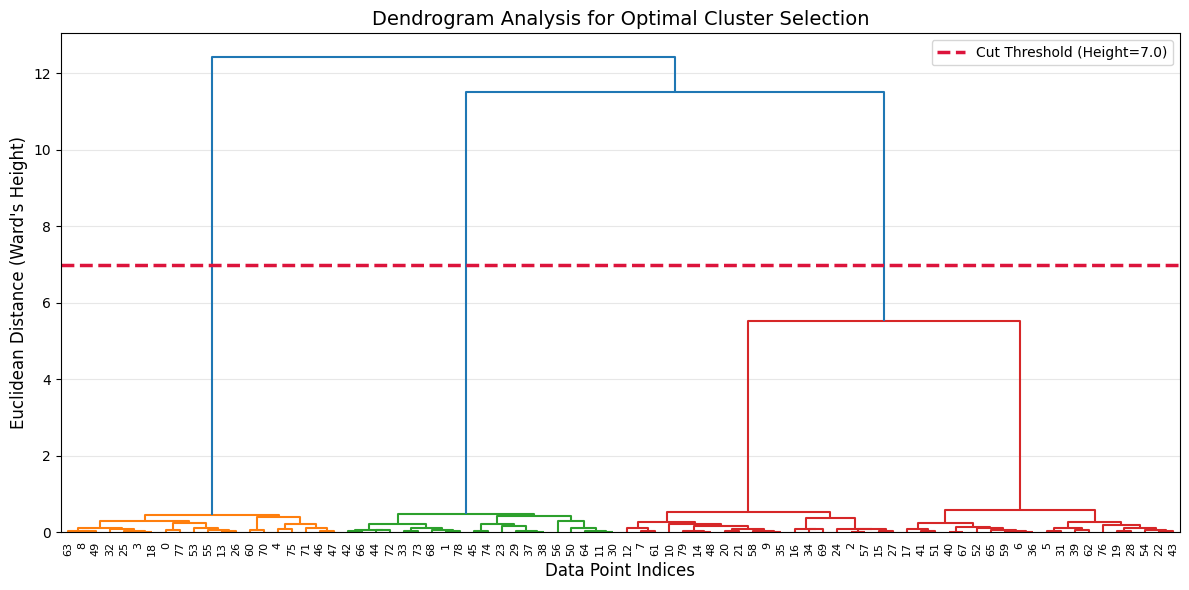

=== HIERARCHICAL SELECTION SUMMARY ===
Dendrogram Threshold cutting gave us: 4 Clusters.
First 15 sample assignments: [3 2 1 3 3 0 0 1 3 1 1 2 1 3 1]


In [4]:
# Topic 135 | Hierarchical Clustering - Dendrograms & Cluster Selection
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# 1. Dataset Generation (4 Naturally occurring groups simulate kar rahe hain)
X, _ = make_blobs(n_samples=80, centers=4, cluster_std=0.55, random_state=42)

# Preprocessing: Distance metrics ke liye standard scaling lazmi hai
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------------
# STEP 2: Matrix Generation using Ward's Linkage
# ------------------------------------------------------------------
Z = linkage(X_scaled, method="ward")

# ------------------------------------------------------------------
# STEP 3: Plotting Dendrogram with Custom Cut Threshold
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# leaf_rotation aur leaf_font_size x-axis ke labels ko clean karne ke liye hain
dend_plot = dendrogram(Z, leaf_rotation=90, leaf_font_size=8)

# Hum visual analysis ke mutabiq vertical gap dekh kar ek threshold line lagate hain
# Farz karein hum height = 7.0 par cut lagate hain
threshold_height = 7.0
plt.axhline(y=threshold_height, color="crimson", linestyle="--", linewidth=2.5, label=f"Cut Threshold (Height={threshold_height})")

plt.title("Dendrogram Analysis for Optimal Cluster Selection", fontsize=14)
plt.xlabel("Data Point Indices", fontsize=12)
plt.ylabel("Euclidean Distance (Ward's Height)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# STEP 4: Applying Scikit-Learn Model based on Cut Analysis
# ------------------------------------------------------------------
# Agar aap dhyan se dekhein toh threshold line 4 vertical lines ko cut karegi
optimal_k = 4
agg_model = AgglomerativeClustering(n_clusters=optimal_k, metric="euclidean", linkage="ward")
cluster_labels = agg_model.fit_predict(X_scaled)

print("=== HIERARCHICAL SELECTION SUMMARY ===")
print(f"Dendrogram Threshold cutting gave us: {optimal_k} Clusters.")
print(f"First 15 sample assignments: {cluster_labels[:15]}")